# Nearest and 2nd-Nearest CC Peaks (Male vs Female)

This notebook reads peak BEDs, annotates with `pycallingcards` (or loads precomputed annotation if available), extracts nearest and 2nd-nearest gene lists (unique genes only), and produces a Venn diagram comparing nearest genes between sexes. Adjust `bedtools_path` if needed.

In [ ]:
# Imports and helper utilities
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import sys

# Optional: matplotlib-venn for Venn diagrams
try:
    from matplotlib_venn import venn2
except Exception:
    venn2 = None

# Paths (edit if you prefer other locations)
WORKDIR = Path('.')
OUTDIR = WORKDIR / 'output' / 'peak_gene_overlaps'
OUTDIR.mkdir(parents=True, exist_ok=True)

# bedtools path used by pycallingcards (adjust to your system)
BEDTOOLS_PATH = '/ref/rmlab/software/pycallingcards/bin'

# Helper to detect gene name columns from annotation outputs
def detect_gene_cols(df):
    # common variants
    choices = ['Gene Name1','Gene Name','Gene','GENE','gene','GeneName','Gene Symbol','SYMBOL','symbol','gene_symbol']
    found = {}
    for c in choices:
        if c in df.columns:
            found[c] = c
    # also look for columns ending with '1' or '2' for nearest/2nd
    for c in df.columns:
        if c.lower().startswith('gene') and c.lower().endswith('1'):
            found[c] = c
    return found

# Try to import pycallingcards (pcc) and warn if missing
pcc = None
try:
    import pycallingcards as pcc
except Exception:
    pcc = None

# Annotate peaks (nearest and 2nd nearest). If pycallingcards is unavailable,
# try to load precomputed annotation files named *_annotated.tsv or *_annotated.csv in the cwd.
def load_or_annotate(prefix, peak_df):
    ann_candidates = list(WORKDIR.glob(f'{prefix}*annotat*.csv')) + list(WORKDIR.glob(f'{prefix}*annotat*.tsv'))
    if ann_candidates:
        print('Loading precomputed annotation:', ann_candidates[0])
        return pd.read_csv(ann_candidates[0], sep=None, engine='python')
    if pcc is None:
        raise RuntimeError('pycallingcards not available and no precomputed annotation found for '+prefix)
    # run annotation through pycallingcards
    print('Annotating', prefix, 'using pycallingcards...')
    ann = pcc.pp.annotation(peak_df, reference='mm10', bedtools_path=BEDTOOLS_PATH)
    ann2 = pcc.pp.combine_annotation(peak_df, ann)
    return ann2

male_ann = load_or_annotate('Male_Egr1CC', peak_data_Male)
female_ann = load_or_annotate('Female_Egr1CC', peak_data_Female)

print('Male annotation rows:', len(male_ann))
print('Female annotation rows:', len(female_ann))


IndentationError: unexpected indent (3499198374.py, line 39)

In [2]:
# Filter by nearest gene distance (<= 20kb) and save
def filter_and_save_ann(df, prefix, dist_col='Distance1', thresh=20000):
    if dist_col not in df.columns:
        raise KeyError(f'{dist_col} not found in annotation columns: {df.columns.tolist()}')
    keep = df[df[dist_col].abs() <= thresh].reset_index(drop=True)
    outfile = OUTDIR / f'{prefix}_peaks_{thresh}bp_nearest_annotated.csv'
    keep.to_csv(outfile, index=False)
    print('Wrote', outfile, 'rows:', len(keep))
    return keep

male_20kb = filter_and_save_ann(male_ann, 'Male_Egr1CC')
female_20kb = filter_and_save_ann(female_ann, 'Female_Egr1CC')

Male peaks loaded: 11977
Female peaks loaded: 11772


In [ ]:
# Extract unique gene lists from nearest (1) and 2nd-nearest (2) columns, save CSVs
import re

def extract_unique_genes(df, prefix):
    # find candidate gene name columns
    candidates = [c for c in df.columns if any(s in c for s in ['Gene','GENE','gene','SYMBOL'])]
    # heuristics for nearest/2nd: look for columns that end with '1' or '2'
    gene1 = None
    gene2 = None
    for c in df.columns:
        if c.endswith('1') and 'Gene' in c:
            gene1 = c
        if c.endswith('2') and 'Gene' in c:
            gene2 = c
    # fallbacks
    if gene1 is None:
        for c in candidates:
            if '1' in c:
                gene1 = c
                break
    if gene2 is None:
        for c in candidates:
            if '2' in c:
                gene2 = c
                break
    # more fallbacks: common names
    if gene1 is None:
        for alt in ['Gene Name1','Gene Name','Gene','SYMBOL','gene_symbol']:
            if alt in df.columns:
                gene1 = alt
                break
    if gene2 is None and 'Gene Name2' in df.columns:
        gene2 = 'Gene Name2'

    def collect_from_series(series):
        s = set()
        if series is None:
            return s
        for val in series.dropna().astype(str):
            val = val.strip()
            if val == '' or val.lower() == 'nan':
                continue
            # split fields that contain multiple gene names (common delimiters)
            parts = re.split(r"[;,\|/]+", val)
            for p in parts:
                p = p.strip()
                if p:
                    s.add(p)
        return s

    genes1 = collect_from_series(df[gene1]) if (gene1 is not None and gene1 in df.columns) else set()
    genes2 = collect_from_series(df[gene2]) if (gene2 is not None and gene2 in df.columns) else set()

    # save
    g1_file = OUTDIR / f'{prefix}_nearest_unique_genes.csv'
    g2_file = OUTDIR / f'{prefix}_2ndnearest_unique_genes.csv'
    pd.Series(sorted(genes1)).to_csv(g1_file, index=False, header=['gene'])
    pd.Series(sorted(genes2)).to_csv(g2_file, index=False, header=['gene'])
    print(prefix, 'unique nearest genes:', len(genes1), '2nd-nearest unique genes:', len(genes2))
    return genes1, genes2, g1_file, g2_file


male_genes1, male_genes2, male_g1_file, male_g2_file = extract_unique_genes(male_20kb, 'Male_Egr1CC')
female_genes1, female_genes2, female_g1_file, female_g2_file = extract_unique_genes(female_20kb, 'Female_Egr1CC')


Annotating Male_Egr1CC using pycallingcards...
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
Annotating Female_Egr1CC using pycallingcards...
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
Male annotation rows: 11977
Female annotation rows: 11772


In [4]:
# Produce Venn diagram comparing nearest genes between sexes
venn_out = OUTDIR / 'venn_nearest_male_vs_female.png'
print('Counts: male nearest =', len(male_genes1), 'female nearest =', len(female_genes1))
inter = male_genes1 & female_genes1
print('Intersection (nearest in both):', len(inter))

if venn2 is None:
    print('matplotlib_venn not installed — install it (pip install matplotlib-venn) to draw Venn diagrams')
else:
    plt.figure(figsize=(6,6))
    venn2([male_genes1, female_genes1], set_labels=('Male nearest','Female nearest'))
    plt.title('Nearest CC peak genes: Male vs Female (unique genes)')
    plt.tight_layout()
    plt.savefig(venn_out, dpi=200)
    print('Wrote Venn diagram to', venn_out)

Wrote output/peak_gene_overlaps/Male_Egr1CC_peaks_20000bp_nearest_annotated.csv rows: 9456
Wrote output/peak_gene_overlaps/Female_Egr1CC_peaks_20000bp_nearest_annotated.csv rows: 9603


In [9]:
# Summary counts and saved file locations
print('Male nearest genes saved to:', male_g1_file)
print('Male 2nd-nearest genes saved to:', male_g2_file)
print('Female nearest genes saved to:', female_g1_file)
print('Female 2nd-nearest genes saved to:', female_g2_file)
print('Intersection size (nearest in both):', len(male_genes1 & female_genes1))
print('Male-only nearest:', len(male_genes1 - female_genes1))
print('Female-only nearest:', len(female_genes1 - male_genes1))

Male_Egr1CC unique nearest genes: 5720 2nd-nearest unique genes: 5983
Female_Egr1CC unique nearest genes: 5833 2nd-nearest unique genes: 6145


Counts: male nearest = 5720 female nearest = 5833
Intersection (nearest in both): 3606
Wrote Venn diagram to output/peak_gene_overlaps/venn_nearest_male_vs_female.png


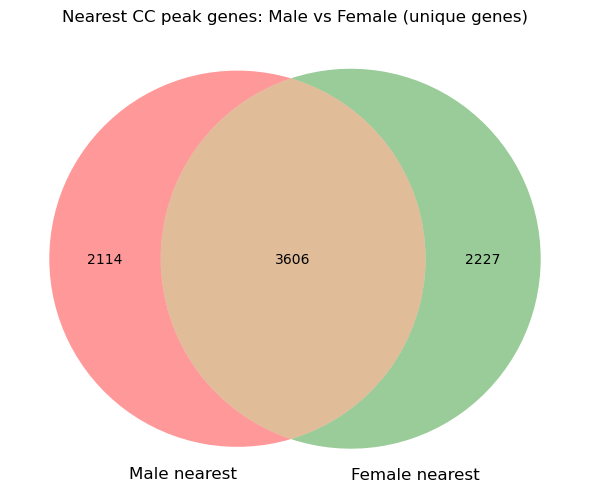

In [10]:
# Produce Venn diagram comparing nearest genes between sexes
venn_out = OUTDIR / 'venn_nearest_male_vs_female.png'
print('Counts: male nearest =', len(male_genes1), 'female nearest =', len(female_genes1))
inter = male_genes1 & female_genes1
print('Intersection (nearest in both):', len(inter))

if venn2 is None:
    print('matplotlib_venn not installed — install it (pip install matplotlib-venn) to draw Venn diagrams')
else:
    plt.figure(figsize=(6,6))
    venn2([male_genes1, female_genes1], set_labels=('Male nearest','Female nearest'))
    plt.title('Nearest CC peak genes: Male vs Female (unique genes)')
    plt.tight_layout()
    plt.savefig(venn_out, dpi=200)
    print('Wrote Venn diagram to', venn_out)

In [11]:
# Summary counts and saved file locations
print('Male nearest genes saved to:', male_g1_file)
print('Male 2nd-nearest genes saved to:', male_g2_file)
print('Female nearest genes saved to:', female_g1_file)
print('Female 2nd-nearest genes saved to:', female_g2_file)
print('Intersection size (nearest in both):', len(male_genes1 & female_genes1))
print('Male-only nearest:', len(male_genes1 - female_genes1))
print('Female-only nearest:', len(female_genes1 - male_genes1))

Male nearest genes saved to: output/peak_gene_overlaps/Male_Egr1CC_nearest_unique_genes.csv
Male 2nd-nearest genes saved to: output/peak_gene_overlaps/Male_Egr1CC_2ndnearest_unique_genes.csv
Female nearest genes saved to: output/peak_gene_overlaps/Female_Egr1CC_nearest_unique_genes.csv
Female 2nd-nearest genes saved to: output/peak_gene_overlaps/Female_Egr1CC_2ndnearest_unique_genes.csv
Intersection size (nearest in both): 3606
Male-only nearest: 2114
Female-only nearest: 2227
